In [2]:
import torch
import matplotlib.pyplot as plt
import random
from pathlib import Path
from PIL import Image
from src import get_model, get_transforms, MODELS_DIR, TEST_DIR
import numpy as np

Running locally. Using D:\Github\Repositories\her2-classification\datasets\Patch-based-dataset as data root.


In [3]:
device = torch.device("cpu")
model = get_model(num_classes=4).to(device)

checkpoint_path = MODELS_DIR / "best_her2_model.pth"
if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch: {checkpoint.get('epoch', 'unknown')}")
    model.eval()
else:
    print("Error: Checkpoint file not found.")

transform = get_transforms(img_size=224, is_train=False)
class_names = ['class_0', 'class_1+', 'class_2+', 'class_3+']

Loaded model from epoch: 2


Actual Class: class_3+
Predicted Class: class_3+


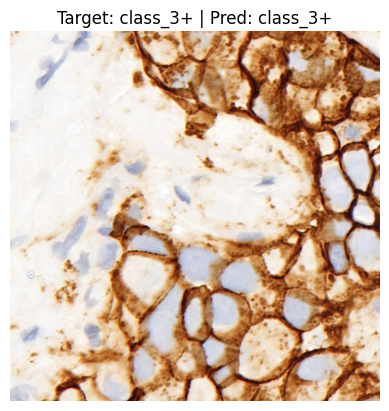

In [17]:
# Select random class and image
random_class = random.choice(class_names)
class_path = TEST_DIR / random_class
random_image_path = random.choice(list(class_path.glob("*.png")))

# Process image
image = Image.open(random_image_path).convert('RGB')
input_tensor = transform(image=np.array(image))['image'].unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)

print(f"Actual Class: {random_class}")
print(f"Predicted Class: {class_names[predicted.item()]}")

plt.imshow(image)
plt.title(f"Target: {random_class} | Pred: {class_names[predicted.item()]}")
plt.axis('off')
plt.show()

In [36]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
from pathlib import Path
from src import get_model, get_transforms, TRAIN_DIR, MODELS_DIR

sns.set_theme(style="white") 

def visualize_model_focus_v3(model_path, image_path, device):

    model = get_model(num_classes=4)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()

    transform = get_transforms(img_size=224, is_train=False)
    original_img = Image.open(image_path).convert('RGB')

    input_tensor = transform(image=np.array(original_img))['image']
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        x = model.conv1(input_batch)
        x = model.bn1(x)
        feature_maps = model.relu(x)


    # -------------------- Seaborn process --------------------  
    
    fig = plt.figure(figsize=(18, 10), layout='constrained')
    
    fig.suptitle(f"HER2 Feature Extraction Analysis\nFile: {image_path.name}", 
                 fontsize=20, fontweight='bold', color='#2c3e50')

    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3])

    # Left side 
    ax_orig = fig.add_subplot(gs[0, 0])
    ax_orig.imshow(original_img)
    ax_orig.set_title("Original Tissue Patch", fontsize=15, pad=20, color='#34495e')
    
    # Delete fames
    sns.despine(ax=ax_orig, left=True, bottom=True)
    ax_orig.set_xticks([])
    ax_orig.set_yticks([])

    # Right side
    inner_grid = fig.add_subfigure(gs[0, 1])
    
    axes = inner_grid.subplots(4, 4)

    for i, ax in enumerate(axes.flat):
        if i < feature_maps.shape[1]:
            f_map = feature_maps[0, i, :, :].cpu().numpy()
            im = ax.imshow(f_map, cmap='mako') 
        ax.axis('off')

    plt.show()

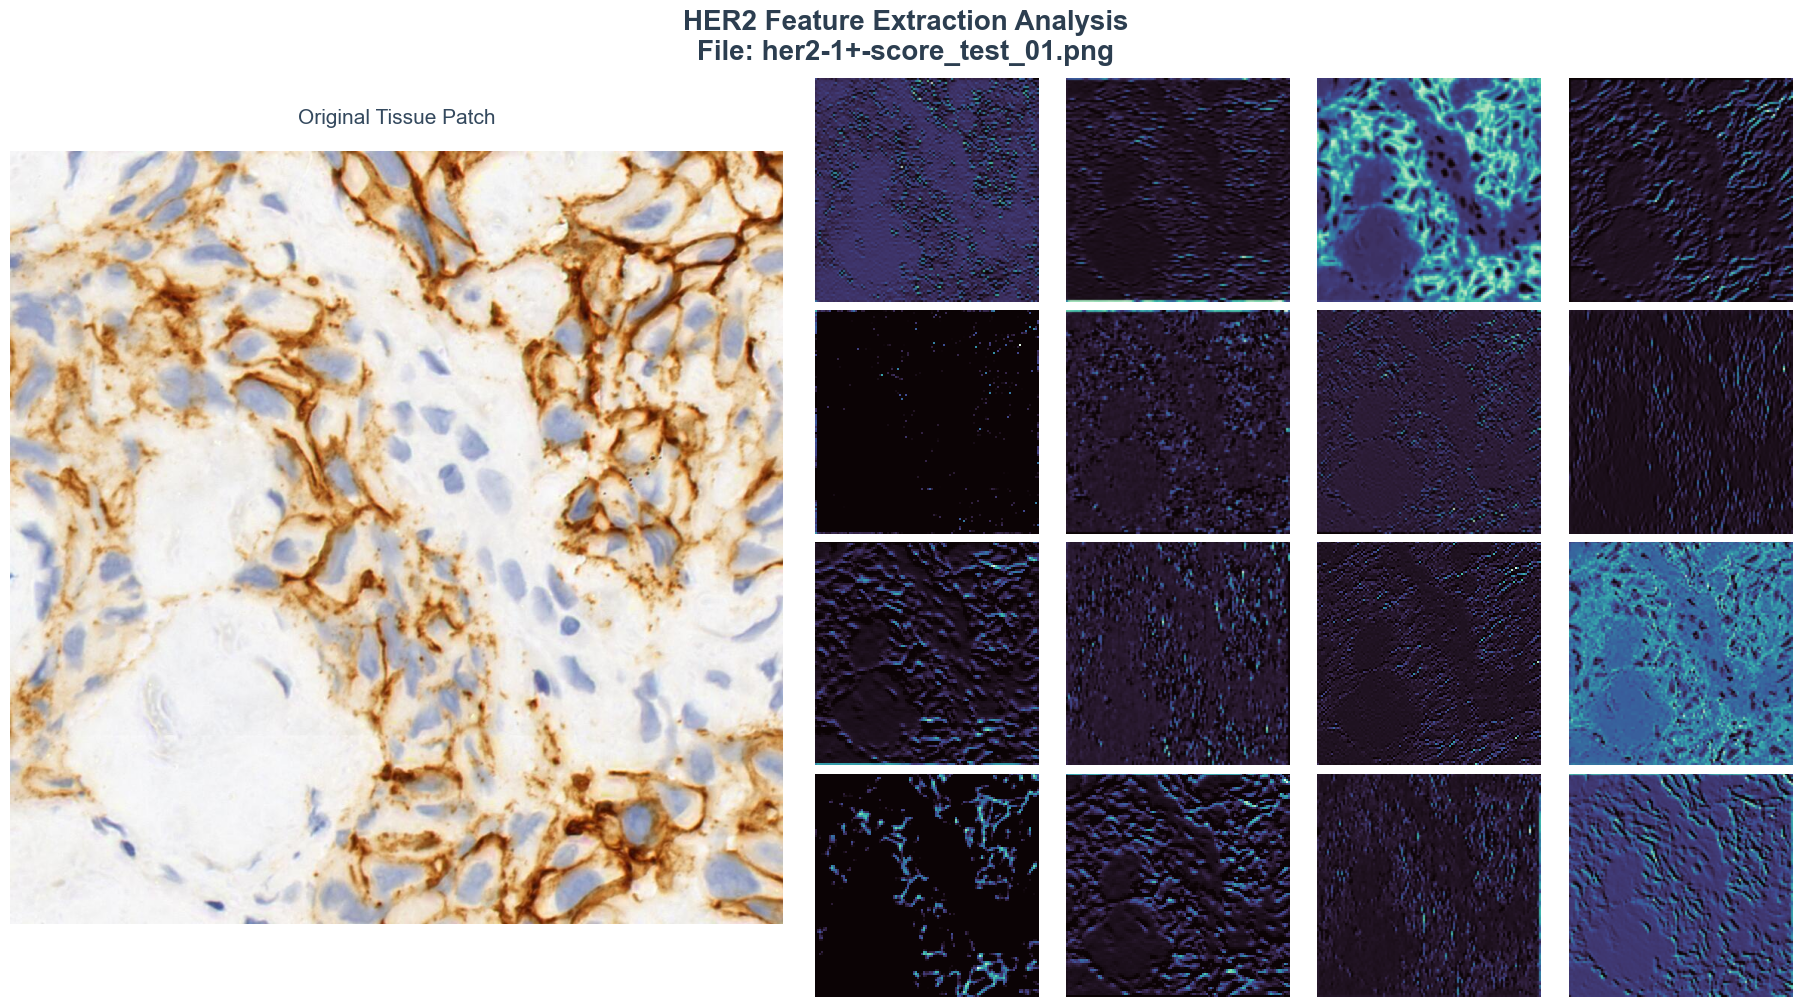

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model_path = MODELS_DIR / "best_her2_model.pth"
sample_img_path = Path(TRAIN_DIR) / "class_3+" / "her2-1+-score_test_01.png"

if best_model_path.exists():
    visualize_model_focus_v3(best_model_path, sample_img_path, device)